In [1]:
%cd /home/ytee/test/trade_bot/
import os
print(os.getcwd())
import numpy as np
from src.pattern.correlation import CORR_MODEL

a =CORR_MODEL(['AUD', 'JPY', 'USD', 'GBP', 'CAD', 'CHF', 'EUR',])


/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot
/home/ytee/test/trade_bot


In [2]:

# target_idx = 10
for target_idx in range(5, 100, 5):
    target_label = 'futrsi'
    mode = 2
    tvt_date=['2000-01-01','2019-01-01', '2024-01-01', '2025-01-01', ]
    m =a.model(target_idx=target_idx, target_label=target_label, mode=mode, 
                tvt_date=tvt_date, 
                force_reset=False)
    X_train, X_val, X_test, y_train, y_val, y_test, header_train, header_val, header_test=a.model(target_idx=target_idx, target_label=target_label, mode=mode, 
                tvt_date=tvt_date, raw=True,
                force_reset=False)


['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2

In [3]:
target_idx = 10
target_label = 'logreturn'
mode = 2
tvt_date=['2000-01-01','2019-01-01', '2024-01-01', '2025-01-01', ]
m =a.model(target_idx=target_idx, target_label=target_label, mode=mode, 
            tvt_date=tvt_date, 
            force_reset=False)
X_train, X_val, X_test, y_train, y_val, y_test, header_train, header_val, header_test=a.model(target_idx=target_idx, target_label=target_label, mode=mode, 
            tvt_date=tvt_date, raw=True,
            force_reset=False)


['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']
['2000-01-01', '2019-01-01', '2024-01-01', '2025-01-01']


date        mu       std
pair                    
AUD   0.230420  3.167077
CAD  -0.396538  2.517910
CHF  -0.239489  2.388258
EUR   0.025969  2.353442
GBP  -1.039159  2.890897
JPY   1.250206  2.918841
USD   0.168590  3.049843
date        mu       std
pair                    
AUD   0.077082  3.026136
CAD  -0.096455  2.641809
CHF  -0.293075  2.769082
EUR   0.063891  2.591809
GBP  -0.177659  2.917803
JPY   0.447238  3.049823
USD  -0.021022  2.884949


<Axes: ylabel='Frequency'>

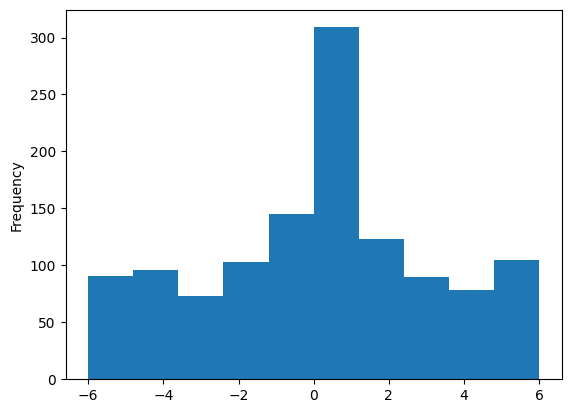

In [4]:
dfval = header_val.copy()
dfval['ret'] = m.predict(X_val)

d1 =dfval.pivot(index='date', columns='pair', values='ret').rank(axis=1)

dfval2 = header_val.copy()
dfval['ret'] = y_val
d2 =dfval.pivot(index='date', columns='pair', values='ret').rank(axis=1)


d3 = d1.copy()

# Apply random permutation to each row (i.e., each date)
for idx in d3.index:
    # Randomly permute the ranks for each date
    d3.loc[idx] = np.random.permutation(d3.loc[idx].values)


dd = (d1-d2).T
dd['mu']= dd.mean(axis=1)
dd['std'] = dd.std(axis=1)

print(dd[['mu', 'std']])


dd = (d3-d2).T
dd['mu']= dd.mean(axis=1)
dd['std'] = dd.std(axis=1)

print(dd[['mu', 'std']])
dd = d3-d2

dd['AUD'].plot(kind='hist')

In [19]:
d3

pair,AUD,CAD,CHF,EUR,GAS,GBP,JPY,OIL,USD,XAG,XAU
date,,,,,,,,,,,
2019-01-02,9.0,4.0,11.0,5.0,7.0,6.0,2.0,3.0,1.0,8.0,10.0
2019-01-03,8.0,1.0,3.0,5.0,11.0,4.0,9.0,6.0,7.0,10.0,2.0
2019-01-04,11.0,6.0,10.0,7.0,2.0,4.0,8.0,1.0,9.0,3.0,5.0
2019-01-07,8.0,7.0,10.0,2.0,5.0,3.0,6.0,9.0,11.0,1.0,4.0
2019-01-08,6.0,11.0,5.0,9.0,4.0,2.0,7.0,3.0,10.0,1.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...
2023-12-21,4.0,1.0,11.0,6.0,7.0,5.0,9.0,10.0,2.0,3.0,8.0
2023-12-22,4.0,1.0,8.0,6.0,9.0,10.0,3.0,11.0,7.0,5.0,2.0
2023-12-27,8.0,5.0,6.0,10.0,1.0,7.0,9.0,4.0,11.0,2.0,3.0


In [5]:
dfval = header_train.copy()
dfval['ret'] = m.predict(X_train)

d1 =dfval.pivot(index='date', columns='pair', values='ret').rank(axis=1)

dfval2 = header_train.copy()
dfval['ret'] = y_train
d2 =dfval.pivot(index='date', columns='pair', values='ret').rank(axis=1)

d3 = d1.copy()

# Apply random permutation to each row (i.e., each date)
for idx in d3.index:
    # Randomly permute the ranks for each date
    d3.loc[idx] = np.random.permutation(d3.loc[idx].values)


dd = (d1-d2).T
dd['mu']= dd.mean(axis=1)
dd['std'] = dd.std(axis=1)

print(dd[['mu', 'std']])


dd = (d3-d2).T
dd['mu']= dd.mean(axis=1)
dd['std'] = dd.std(axis=1)

print(dd[['mu', 'std']])


# dd['AUD'].plot(kind='hist')

date        mu       std
pair                    
AUD  -0.071228  1.743450
CAD   0.030912  1.758961
CHF  -0.116407  1.737631
EUR   0.025616  1.610179
GBP   0.095223  1.691981
JPY   0.156939  1.647297
USD  -0.121055  1.705907
date        mu       std
pair                    
AUD  -0.169801  2.951561
CAD  -0.033939  2.803234
CHF  -0.015888  2.720202
EUR  -0.021725  2.668553
GBP   0.026913  2.789870
JPY   0.141159  3.044270
USD   0.073281  2.833931
